# Curtailed Energy Analysis

**Notebook 01 in the Curtailed-2-Compute Analysis Workflow**

This notebook provides comprehensive analysis of renewable energy curtailment patterns in California using CAISO data. This is the first step in the analysis workflow.

## Overview

This analysis examines:
- Temporal patterns of solar and wind curtailment
- Daily, monthly, and yearly trends
- Seasonal variations (duck curve patterns)
- Local vs. system-wide curtailment events

## Workflow Position

- **Input**: Raw CAISO curtailment Excel files
- **Output**: Processed curtailment data used in `02_TAC.ipynb` and `03_lmp_vectors.ipynb`

## Data Source

- **Source**: CAISO Managing Oversupply Reports
- **Format**: Excel files (`productionandcurtailmentsdata_YYYY.xlsx`)
- **Location**: `../data/` or `../misc/archived_files/` directory
- **Temporal Resolution**: 5-minute intervals
- **Coverage**: 2020-2025 (as available)

## Key Definitions

- **Curtailment**: The intentional reduction of renewable generation when supply exceeds demand
- **Solar Curtailment**: Curtailed solar energy in MW (converted to MWh for analysis)
- **Wind Curtailment**: Curtailed wind energy in MW (converted to MWh for analysis)
- **Local Curtailment**: Due to localized grid constraints (transmission congestion, limited local load)
- **System Curtailment**: Due to system-wide oversupply (total renewable generation exceeds total demand)

## Energy Conversion

For 5-minute intervals:
```
MWh = MW × (5 minutes / 60 minutes) = MW × 0.0833
```

## Outputs

This notebook generates:
- Daily, monthly, and yearly aggregation files (saved to `../outputs/`)
- Visualization plots showing curtailment trends
- Statistical summaries of curtailment patterns



## Data Requirements

### Source Data Files Needed

This notebook requires CAISO curtailment Excel files. These are **not included in the repository** due to their large size.

**To obtain the data**:
1. Visit [CAISO Managing Oversupply Reports](https://www.caiso.com/informed/Pages/ManagingOversupply.aspx)
2. Navigate to "Production and Curtailments Data"
3. Download Excel files for desired years
4. File format: `productionandcurtailmentsdata_YYYY.xlsx` (e.g., `productionandcurtailmentsdata_2024.xlsx`)
5. Place files in one of these locations:
   - `../data/` directory, OR
   - `../misc/archived_files/` directory

**Expected files for full analysis**:
- `productionandcurtailmentsdata_2020.xlsx`
- `productionandcurtailmentsdata_2021.xlsx`
- `productionandcurtailmentsdata_2022.xlsx`
- `productionandcurtailmentsdata_2023.xlsx`
- `productionandcurtailmentsdata_2024.xlsx`
- `productionandcurtailmentsdata_2025.xlsx` (if available)

**Note**: The notebook will attempt to load files for years 2020-2025. Missing files will be skipped with a warning.

**File size**: Each file is typically 5-20 MB depending on the year.



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)

In [ ]:
# ---------------------------------------------
# STEP 1: Load and Combine Yearly Excel Files
# ---------------------------------------------
# Try multiple possible locations for curtailment data
data_dir = Path("../data")
archived_dir = Path("../misc/archived_files")
years = [2020, 2021, 2022, 2023, 2024, 2025]
combined_df = []

for year in years:
    # Try data directory first, then archived_files directory
    file = data_dir / f"productionandcurtailmentsdata_{year}.xlsx"
    if not file.exists():
        file = archived_dir / f"productionandcurtailmentsdata_{year}.xlsx"
    
    try:
        if file.exists():
            xl = pd.ExcelFile(file)
            df = xl.parse("Curtailments")
            df['Year'] = year
            combined_df.append(df)
            print(f"✓ Loaded {file.name} from {file.parent}")
        else:
            print(f"⚠ File not found: productionandcurtailmentsdata_{year}.xlsx (searched in {data_dir} and {archived_dir})")
    except Exception as e:
        print(f"Error loading {file.name}: {e}")

# Validate that we loaded at least some data
if not combined_df:
    raise ValueError(
        "No curtailment data files were successfully loaded. "
        "Please ensure CAISO curtailment Excel files are available in "
        "../data/ or ../misc/archived_files/ directories. "
        "See the 'Data Requirements' section above for download instructions."
    )

curtailment_df = pd.concat(combined_df, ignore_index=True)

# Validate that the dataframe is not empty
if curtailment_df.empty:
    raise ValueError(
        "Loaded curtailment data is empty. Please check the data files."
    )

print(f"\n✓ Successfully loaded {len(curtailment_df):,} records")
print(f"  Date range: {curtailment_df['Date'].min()} to {curtailment_df['Date'].max()}")

# ---------------------------------------------
# STEP 2: Clean and Enrich Columns
# ---------------------------------------------
# Fix pandas FutureWarning: Use .copy() and proper assignment instead of inplace
curtailment_df = curtailment_df.copy()
curtailment_df['Wind Curtailment'] = curtailment_df['Wind Curtailment'].fillna(0)

# Calculate total curtailed MW per interval
# Note: Curtailment values are in MW (instantaneous power) at 5-minute intervals
curtailment_df['Total Curtailment (MW)'] = (
    curtailment_df['Solar Curtailment'] + curtailment_df['Wind Curtailment']
)

# Build datetime column (5-minute intervals)
# CAISO data uses Date, Hour (1-24), and Interval (1-12) columns
# Hour 1 = 00:00-00:59, Interval 1 = first 5 minutes of that hour
curtailment_df['Datetime'] = pd.to_datetime(curtailment_df['Date']) + pd.to_timedelta(
    (curtailment_df['Hour'] - 1) * 60 + (curtailment_df['Interval'] - 1) * 5, unit='m'
)

# Convert MW to MWh for energy calculations
# For 5-minute intervals: Energy (MWh) = Power (MW) × Time (hours)
# 5 minutes = 5/60 hours = 0.0833 hours
CONVERSION_FACTOR = 5 / 60  # 5 minutes to hours
for col in ['Solar Curtailment', 'Wind Curtailment', 'Total Curtailment (MW)']:
    curtailment_df[f"{col} (MWh)"] = curtailment_df[col] * CONVERSION_FACTOR

# Add Month_Num and Year for temporal analysis
curtailment_df['Month_Num'] = curtailment_df['Datetime'].dt.month
curtailment_df['Year'] = curtailment_df['Datetime'].dt.year


✓ Loaded productionandcurtailmentsdata_2020.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2021.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2022.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2023.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2024.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2025.xlsx from ../misc/archived_files


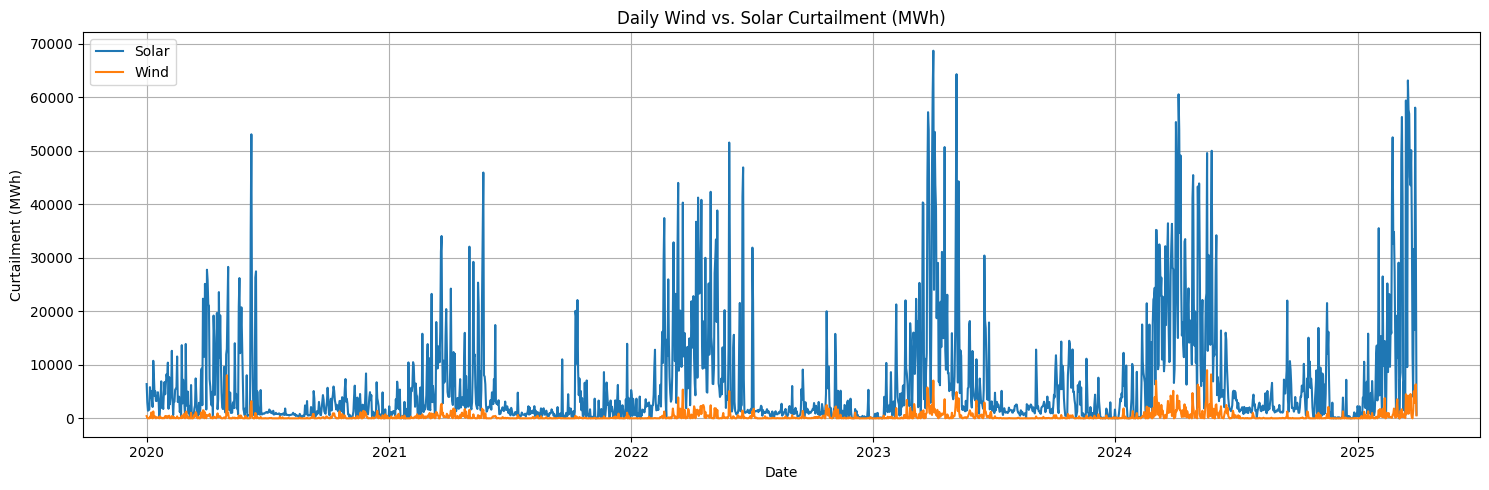

<Figure size 1200x600 with 0 Axes>

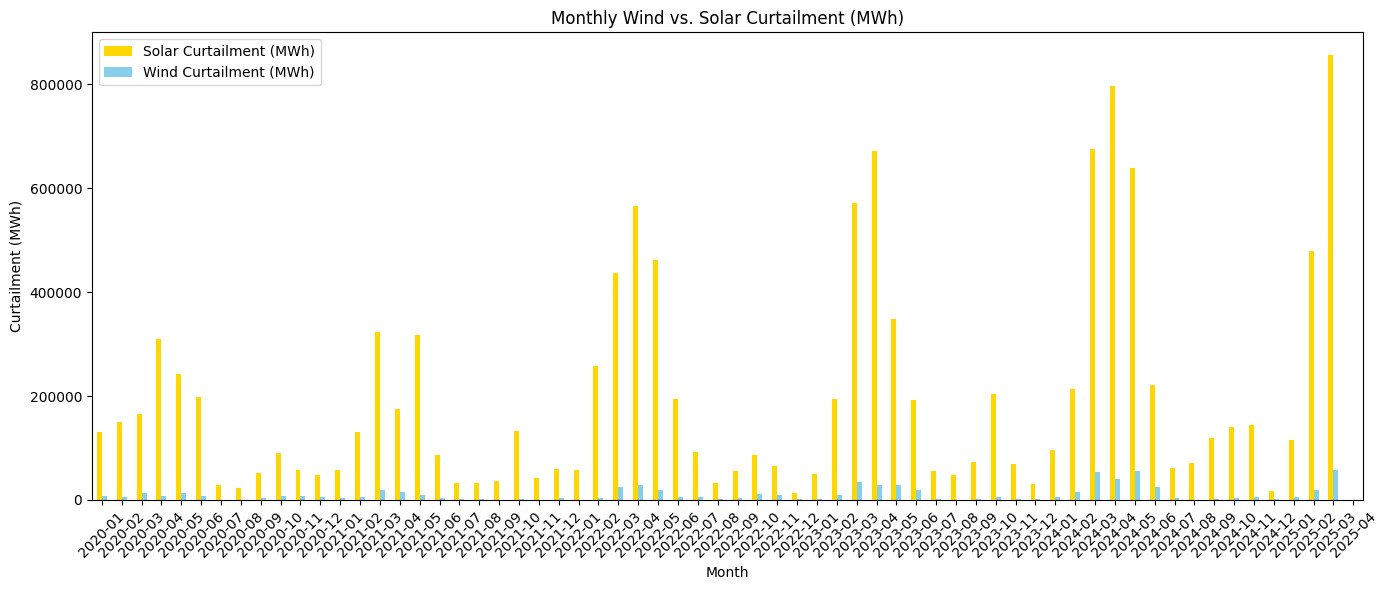

<Figure size 800x500 with 0 Axes>

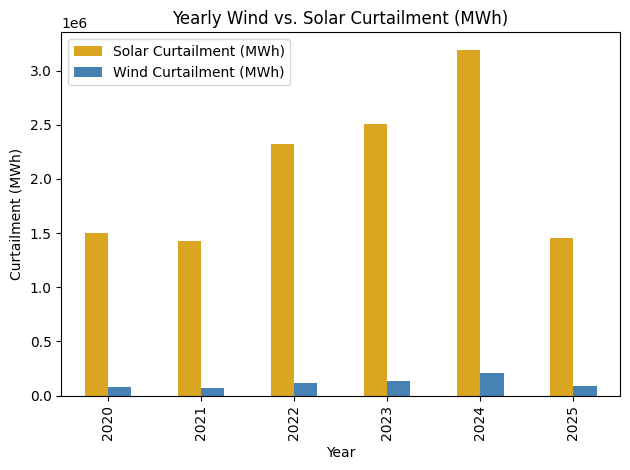

In [26]:
# Create aggregated views of solar and wind curtailment over time
# Drop rows with missing values to ensure clean aggregation

curtailment_df_clean = curtailment_df.copy()
curtailment_df_clean['Date'] = pd.to_datetime(curtailment_df_clean['Date'])
curtailment_df_clean['Month'] = curtailment_df_clean['Datetime'].dt.to_period('M')
curtailment_df_clean['Month_Num'] = curtailment_df_clean['Datetime'].dt.month
curtailment_df_clean['Year'] = curtailment_df_clean['Datetime'].dt.year
curtailment_df_clean = curtailment_df_clean.dropna(subset=['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)'])

# Daily totals
daily_curtailment = curtailment_df_clean.groupby(curtailment_df_clean['Date'].dt.date)[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']
].sum().reset_index()

# Monthly totals
monthly_curtailment = curtailment_df_clean.groupby(curtailment_df_clean['Month'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']
].sum().reset_index()

# Yearly totals
yearly_curtailment = curtailment_df_clean.groupby(curtailment_df_clean['Year'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']
].sum().reset_index()

# Plot daily curtailment
plt.figure(figsize=(15, 5))
sns.lineplot(data=daily_curtailment, x='Date', y='Solar Curtailment (MWh)', label='Solar')
sns.lineplot(data=daily_curtailment, x='Date', y='Wind Curtailment (MWh)', label='Wind')
plt.title("Daily Wind vs. Solar Curtailment (MWh)")
plt.xlabel("Date")
plt.ylabel("Curtailment (MWh)")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# Plot monthly curtailment
plt.figure(figsize=(12, 6))
monthly_curtailment['Month'] = monthly_curtailment['Month'].astype(str)  # for x-axis labels
monthly_curtailment.set_index('Month')[['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']].plot(
    kind='bar', stacked=False, figsize=(14, 6), color=['gold', 'skyblue']
)
plt.title("Monthly Wind vs. Solar Curtailment (MWh)")
plt.xlabel("Month")
plt.ylabel("Curtailment (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot yearly curtailment
plt.figure(figsize=(8, 5))
yearly_curtailment.set_index('Year')[['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)']].plot(
    kind='bar', stacked=False, color=['goldenrod', 'steelblue']
)
plt.title("Yearly Wind vs. Solar Curtailment (MWh)")
plt.xlabel("Year")
plt.ylabel("Curtailment (MWh)")
plt.tight_layout()
plt.show()


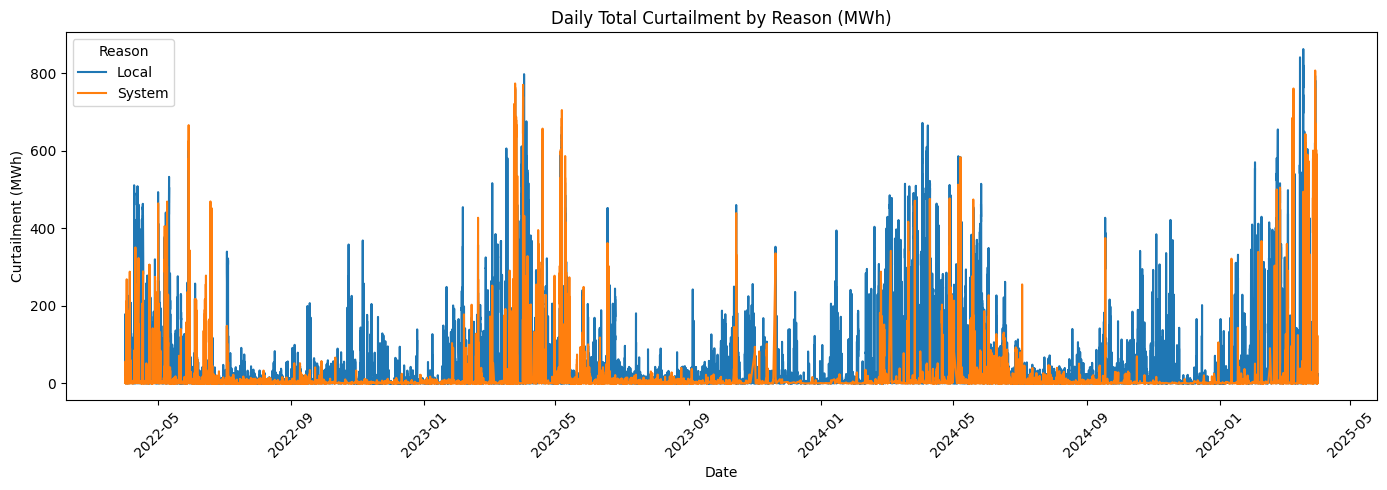

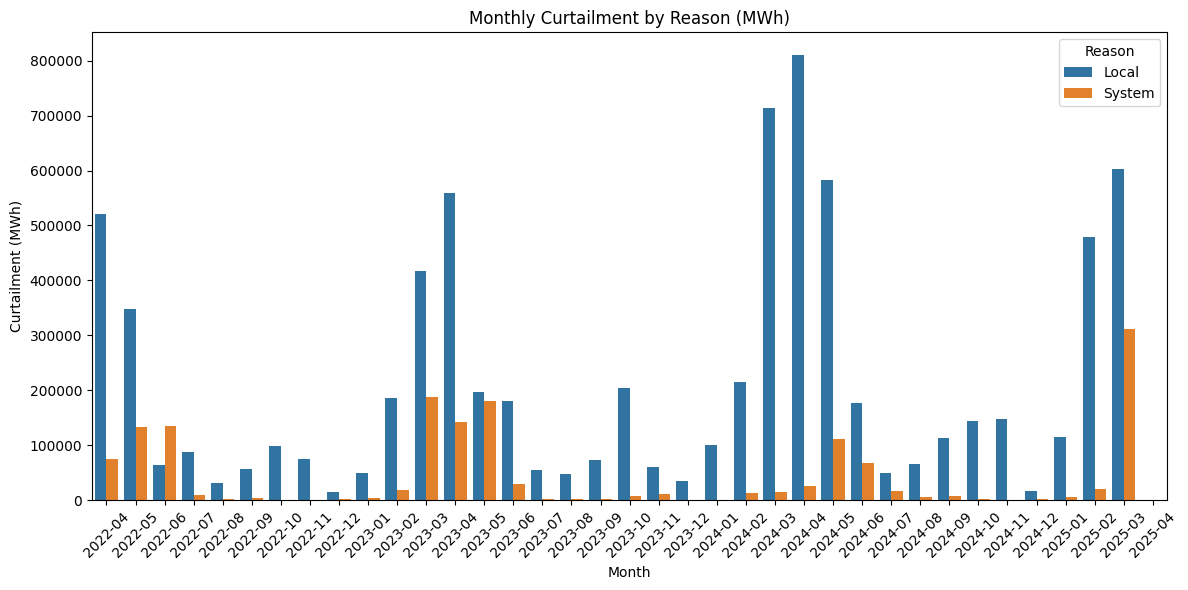

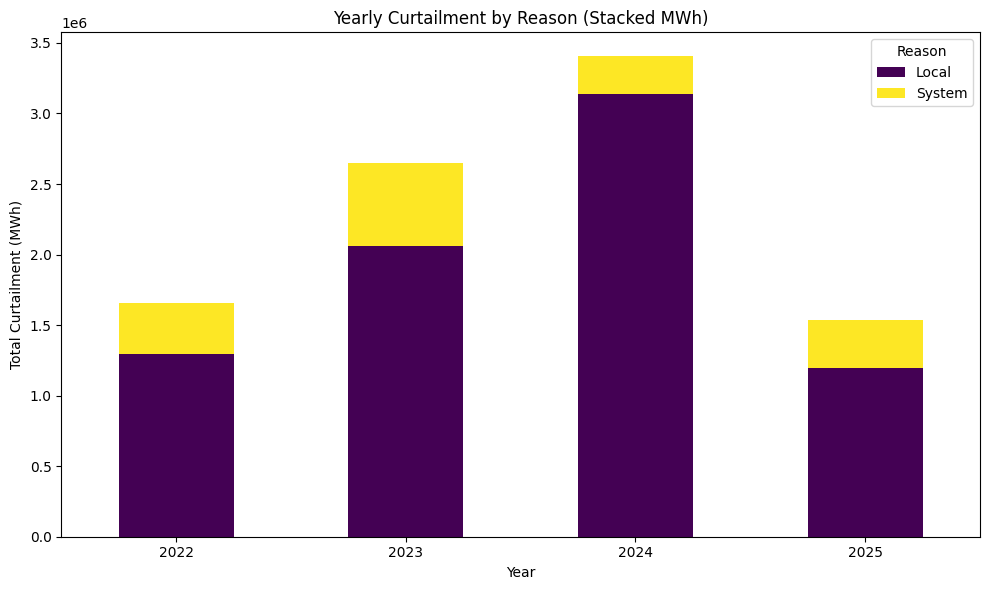

In [27]:
# ---------------------------------------------
# STEP 4: Aggregate by Time and Reason
# ---------------------------------------------
daily =  curtailment_df_clean.groupby(['Datetime', 'Reason'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)', 'Total Curtailment (MW) (MWh)']
].sum().reset_index()
daily['Date'] = daily['Datetime'].dt.date

# Monthly summary
monthly = curtailment_df_clean.groupby(['Month', 'Reason'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)', 'Total Curtailment (MW) (MWh)']
].sum().reset_index()

# Yearly summary
yearly = curtailment_df_clean.groupby(['Year', 'Reason'])[
    ['Solar Curtailment (MWh)', 'Wind Curtailment (MWh)', 'Total Curtailment (MW) (MWh)']
].sum().reset_index()

# ---------------------------------------------
# DAILY CURTAILMENT TRENDS
# ---------------------------------------------
plt.figure(figsize=(14, 5))
sns.lineplot(data=daily, x="Datetime", y="Total Curtailment (MW) (MWh)", hue="Reason")
plt.title("Daily Total Curtailment by Reason (MWh)")
plt.xlabel("Date")
plt.ylabel("Curtailment (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# MONTHLY CURTAILMENT COMPARISON
# ---------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly, x="Month", y="Total Curtailment (MW) (MWh)", hue="Reason")
plt.title("Monthly Curtailment by Reason (MWh)")
plt.xlabel("Month")
plt.ylabel("Curtailment (MWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# YEARLY CURTAILMENT STACKED BAR
# ---------------------------------------------
pivot_yearly = yearly.pivot(index="Year", columns="Reason", values="Total Curtailment (MW) (MWh)")
pivot_yearly.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Yearly Curtailment by Reason (Stacked MWh)")
plt.xlabel("Year")
plt.ylabel("Total Curtailment (MWh)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [28]:
yearly_curtailment

,Year,Solar Curtailment (MWh),Wind Curtailment (MWh)
0,2020,1.497220e+06,82326.623818
1,2021,1.426326e+06,68310.158513
2,2022,2.320258e+06,117564.310791
3,2023,2.508923e+06,137096.106369
4,2024,3.192600e+06,212301.104495
5,2025,1.451773e+06,84235.807207


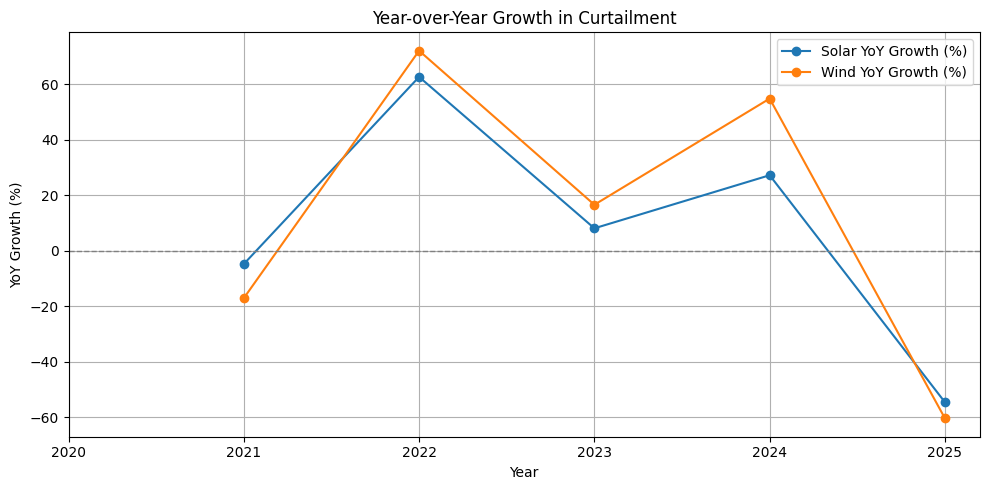

In [29]:
# Compute YoY growth
yearly_curtailment['Solar YoY Growth (%)'] = yearly_curtailment['Solar Curtailment (MWh)'].pct_change() * 100
yearly_curtailment['Wind YoY Growth (%)'] = yearly_curtailment['Wind Curtailment (MWh)'].pct_change() * 100

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(yearly_curtailment['Year'], yearly_curtailment['Solar YoY Growth (%)'], marker='o', label='Solar YoY Growth (%)')
plt.plot(yearly_curtailment['Year'], yearly_curtailment['Wind YoY Growth (%)'], marker='o', label='Wind YoY Growth (%)')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Fix x-axis ticks
plt.xticks(yearly_curtailment['Year'])

plt.title('Year-over-Year Growth in Curtailment')
plt.xlabel('Year')
plt.ylabel('YoY Growth (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

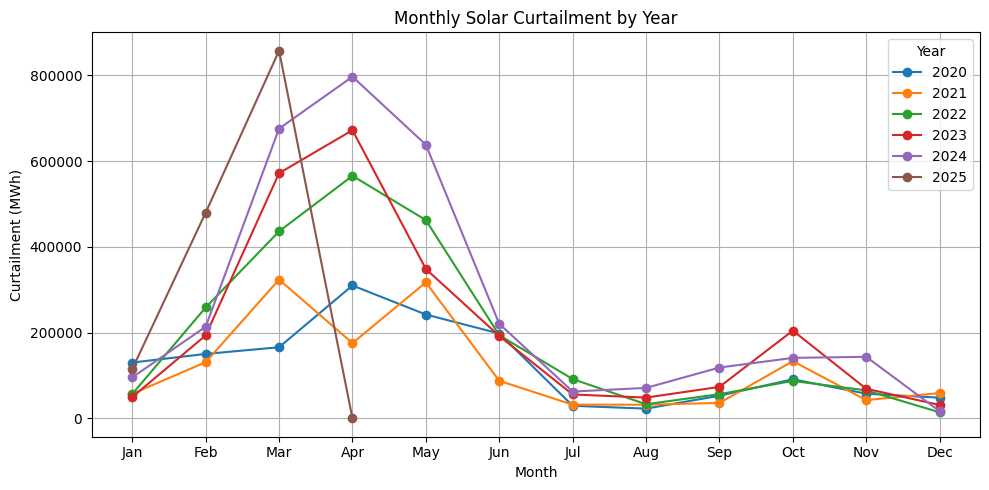

In [30]:
# Assume monthly_curtailment is already loaded
monthly_curtailment['Month'] = pd.to_datetime(monthly_curtailment['Month'])
monthly_curtailment['Year'] = monthly_curtailment['Month'].dt.year
monthly_curtailment['Month_Num'] = monthly_curtailment['Month'].dt.month

# Group by Year and Month_Num for Solar
pivot_solar = monthly_curtailment.pivot(index='Month_Num', columns='Year', values='Solar Curtailment (MWh)')

# Plot solar
plt.figure(figsize=(10, 5))
for year in pivot_solar.columns:
    plt.plot(pivot_solar.index, pivot_solar[year], marker='o', label=str(year))
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Solar Curtailment by Year')
plt.xlabel('Month')
plt.ylabel('Curtailment (MWh)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

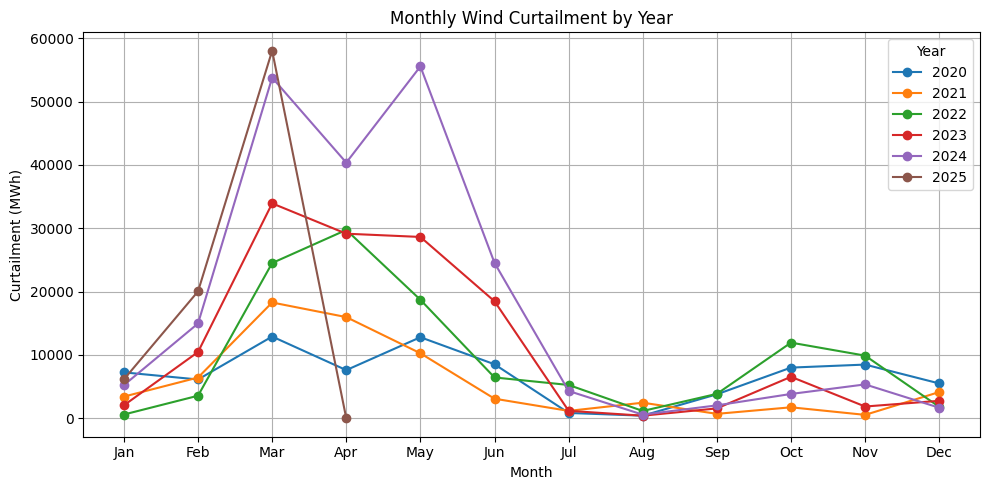

In [31]:
# Repeat for Wind
pivot_wind = monthly_curtailment.pivot(index='Month_Num', columns='Year', values='Wind Curtailment (MWh)')

plt.figure(figsize=(10, 5))
for year in pivot_wind.columns:
    plt.plot(pivot_wind.index, pivot_wind[year], marker='o', label=str(year))
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Wind Curtailment by Year')
plt.xlabel('Month')
plt.ylabel('Curtailment (MWh)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

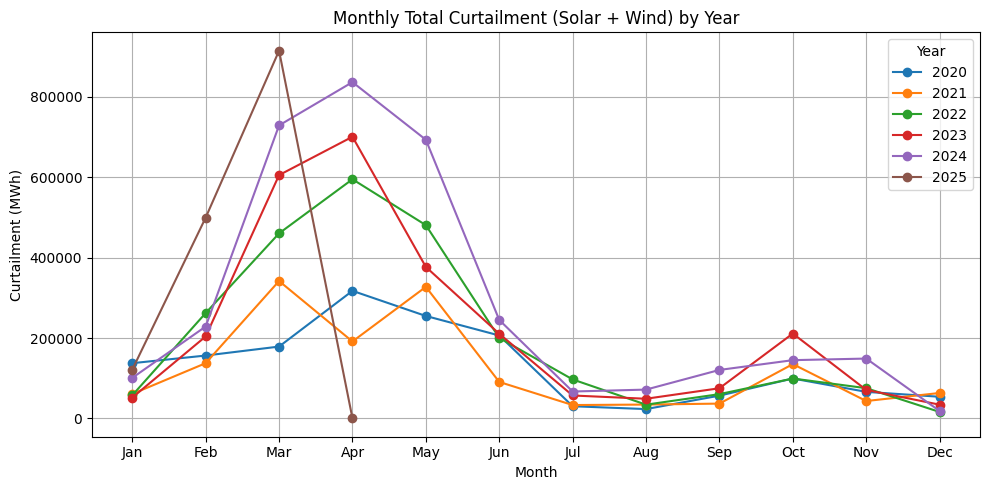

In [32]:
# Add a combined curtailment column
monthly_curtailment['Total Curtailment (MWh)'] = (
    monthly_curtailment['Solar Curtailment (MWh)'] + monthly_curtailment['Wind Curtailment (MWh)']
)

# Pivot for combined curtailment
pivot_total = monthly_curtailment.pivot(index='Month_Num', columns='Year', values='Total Curtailment (MWh)')

# Plot total curtailment
plt.figure(figsize=(10, 5))
for year in pivot_total.columns:
    plt.plot(pivot_total.index, pivot_total[year], marker='o', label=str(year))
plt.xticks(range(1,13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Monthly Total Curtailment (Solar + Wind) by Year')
plt.xlabel('Month')
plt.ylabel('Curtailment (MWh)')
plt.legend(title='Year')
plt.grid(True)
plt.tight_layout()
plt.show()

## Duck Curve and Seasonal Curtailment Patterns

Solar curtailment occurs most frequently in spring and fall when demand is low because moderate weather, and sunny, breezy days produce an abundant supply of renewable generation. ([Source: CAISO](https://www.caiso.com/about/our-business/managing-the-evolving-grid))

### The "Duck Curve"

CAISO refers to the **duck curve** — a sharp ramp in net demand during the late afternoon as solar drops off and customer demand rises. Managing this requires more flexible resources to avoid overgeneration during the day and scarcity at night.

The duck curve pattern is characterized by:
- **Low net demand during midday**: High solar generation reduces the need for other resources
- **Rapid ramp-up in evening**: As solar generation declines, demand increases quickly
- **Peak demand in evening**: Evening hours require significant flexible generation capacity

## Hourly Average Curtailment Analysis

The following analysis computes the **mean curtailment at each hour of the day** to identify temporal patterns.

For example: *"How much solar curtailment happens on average at 12pm in April?"*

### Important Note on Interpretation

The hourly average analysis shows **temporal patterns** (when curtailment typically occurs), but **not total daily volume**. 

If you sum those hourly average values, the total is much smaller (e.g., ~1,700 MWh/day) than actual daily totals, because:
- It **smooths over intra-hour spikes** (averaging reduces peak values)
- It **averages across sparse curtailment days** (includes days with zero curtailment)

For total daily volume, see the daily aggregation analysis in earlier cells.


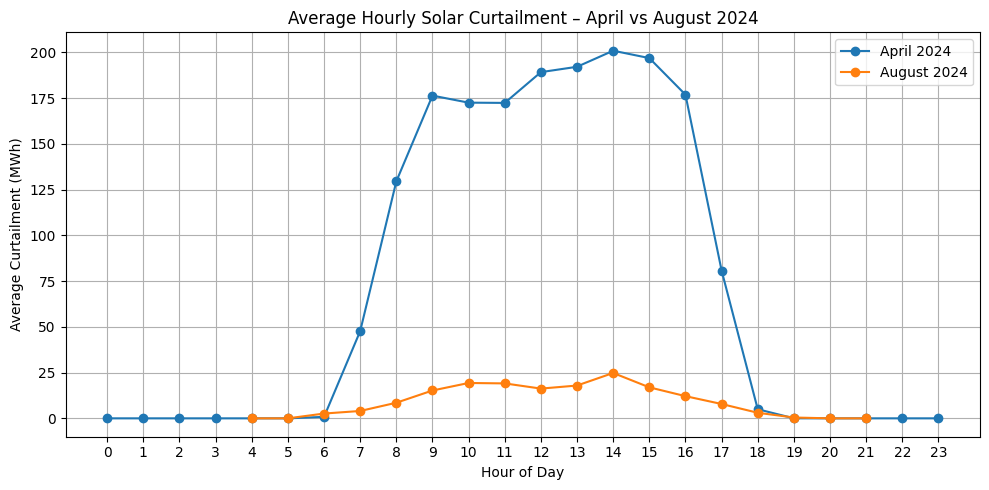

In [33]:
# Filter April 2024 data
#curtailment_df['Datetime'] = pd.to_datetime(curtailment_df['Datetime'])
curtailment_df['Datetime'] = curtailment_df['Datetime'] - pd.Timedelta(hours=7)
# Filter April 2024
df_april = curtailment_df[
    (curtailment_df['Datetime'].dt.month == 4) & (curtailment_df['Datetime'].dt.year == 2024)
].copy()

# Filter August 2024
df_august = curtailment_df[
    (curtailment_df['Datetime'].dt.month == 8) & (curtailment_df['Datetime'].dt.year == 2024)
].copy()

# Extract hour and fill NaNs
for df in [df_april, df_august]:
    df['Hour'] = df['Datetime'].dt.hour
    df['Solar Curtailment (MWh)'] = df['Solar Curtailment (MWh)'].fillna(0)

# Group by hour and compute averages
avg_april = df_april.groupby('Hour')['Solar Curtailment (MWh)'].mean()
avg_august = df_august.groupby('Hour')['Solar Curtailment (MWh)'].mean()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(avg_april.index, avg_april.values, marker='o', label='April 2024')
plt.plot(avg_august.index, avg_august.values, marker='o', label='August 2024')
plt.title('Average Hourly Solar Curtailment – April vs August 2024')
plt.xlabel('Hour of Day')
plt.ylabel('Average Curtailment (MWh)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



In [34]:
# ---------------------------------------------
# STEP 1: Load and Combine Yearly Excel Files (Production sheet)
# ---------------------------------------------
# Try multiple possible locations for curtailment data
data_dir = Path("../data")
archived_dir = Path("../misc/archived_files")
years = [2020, 2021, 2022, 2023, 2024, 2025]
production_combined = []

for year in years:
    # Try data directory first, then archived_files directory
    file = data_dir / f"productionandcurtailmentsdata_{year}.xlsx"
    if not file.exists():
        file = archived_dir / f"productionandcurtailmentsdata_{year}.xlsx"
    
    try:
        if file.exists():
            xl = pd.ExcelFile(file)
            df_prod = xl.parse("Production")
            df_prod['Year'] = year
            production_combined.append(df_prod)
            print(f"✓ Loaded {file.name} from {file.parent}")
        else:
            print(f"⚠ File not found: productionandcurtailmentsdata_{year}.xlsx (searched in {data_dir} and {archived_dir})")
    except Exception as e:
        print(f"Error loading {file.name}: {e}")

production_df = pd.concat(production_combined, ignore_index=True)

# Ensure 'Date' is parsed as datetime
production_df['Date'] = pd.to_datetime(production_df['Date'])

✓ Loaded productionandcurtailmentsdata_2020.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2021.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2022.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2023.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2024.xlsx from ../misc/archived_files
✓ Loaded productionandcurtailmentsdata_2025.xlsx from ../misc/archived_files


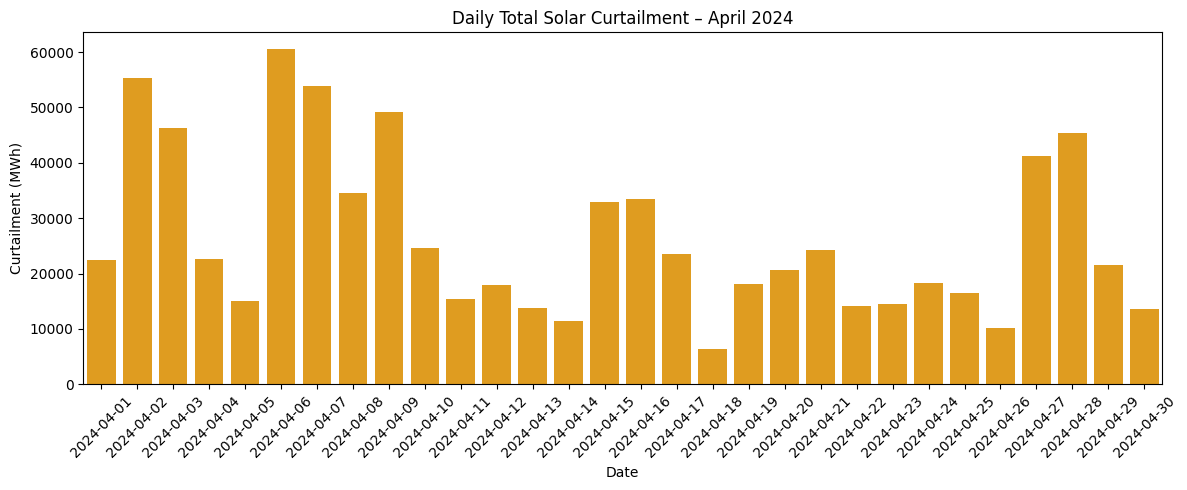

In [35]:
# Daily total solar curtailment
df_april['Date'] = df_april['Datetime'].dt.date
daily_totals = df_april.groupby('Date')['Solar Curtailment (MWh)'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 5))
sns.barplot(data=daily_totals, x='Date', y='Solar Curtailment (MWh)', color='orange')
plt.xticks(rotation=45)
plt.title("Daily Total Solar Curtailment – April 2024")
plt.ylabel("Curtailment (MWh)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

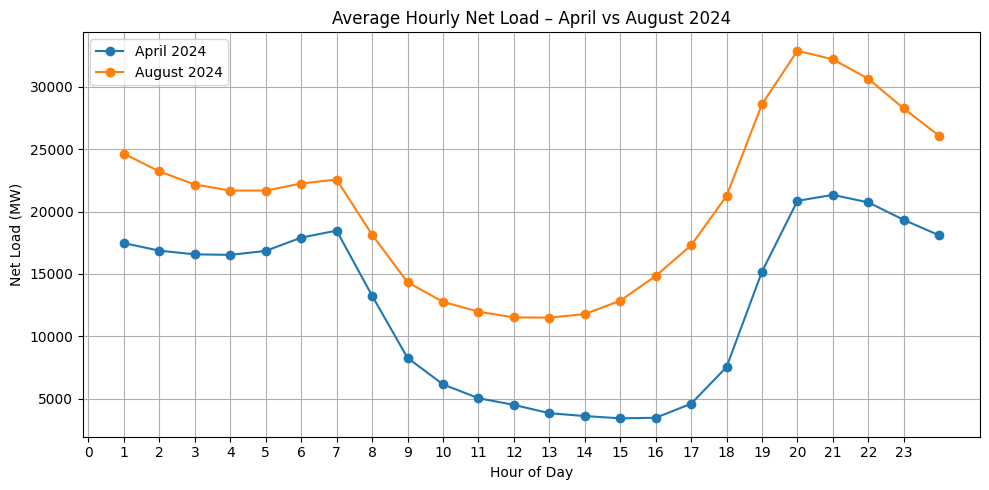

In [36]:
# Ensure Hour is integer and Date is datetime
production_df['Hour'] = production_df['Hour'].astype(int)
#production_df['Date'] = pd.to_datetime(production_df['Date'])

# Filter April 2024
df_april = production_df[
    (production_df['Date'].dt.month == 4) & (production_df['Date'].dt.year == 2024)
].copy()

# Filter August 2024
df_august = production_df[
    (production_df['Date'].dt.month == 8) & (production_df['Date'].dt.year == 2024)
].copy()

# Compute average hourly net load
avg_april = df_april.groupby('Hour')['Net Load'].mean()
avg_august = df_august.groupby('Hour')['Net Load'].mean()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(avg_april.index, avg_april.values, marker='o', label='April 2024')
plt.plot(avg_august.index, avg_august.values, marker='o', label='August 2024')
plt.title('Average Hourly Net Load – April vs August 2024')
plt.xlabel('Hour of Day')
plt.ylabel('Net Load (MW)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


1. Clear temporal patterns
Curtailment spikes midday → aligns with solar generation peak.
Spring months (especially April) show high average curtailment → matches real-world CAISO reports.
These point to strong seasonality + diurnal structure.

2. Year-over-year growth trend
Total curtailed MWh is increasing, especially for solar.
There’s a structural oversupply problem, not just a weather-driven one.

3. Curtailment timing aligns with net load dips, Midday → High Solar Output → Net Load Drops → Oversupply → Curtailment
Solar generation depresses net load during certain hours, creating curtailment pressure.

Curtailment is a forecastable quantity influenced by:
Time features (hour, month, weekday)

Supply capacity (installed solar/wind MW over time)

Demand (total load, net load trends)

Storage deployment (batteries reduce curtailment)

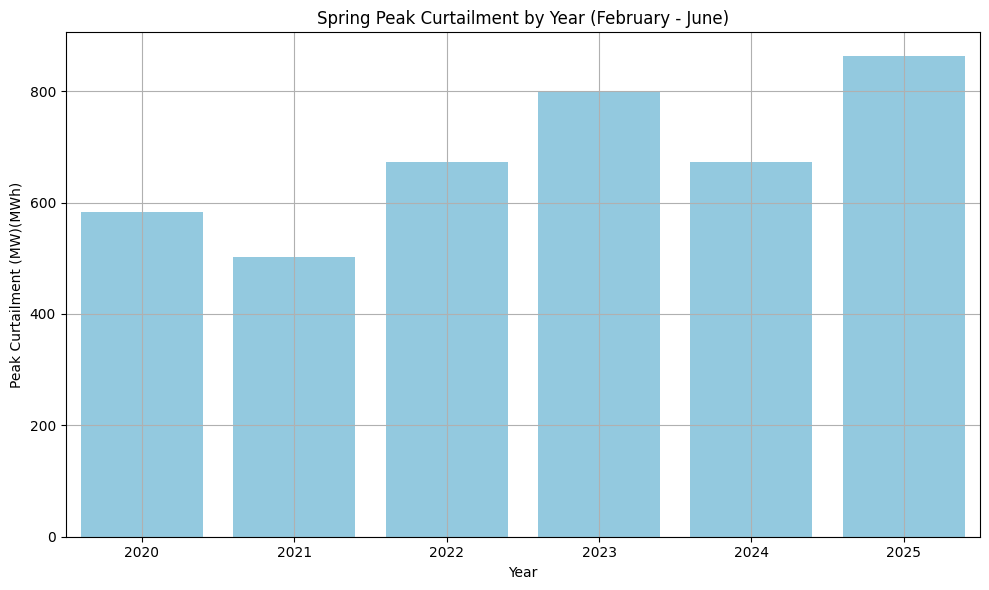

In [37]:
# Define spring months for analysis (March, April, May)
spring_months = [2, 3, 4, 5, 6]
spring_df = curtailment_df[curtailment_df['Month_Num'].isin(spring_months)]

# Group by year and calculate metrics
spring_summary = spring_df.groupby('Year')['Total Curtailment (MW) (MWh)'].agg(
    Spring_Total_Curtailment_MWh='sum',
    Spring_Average_Daily_Curtailment_MWh='mean',
    Spring_Peak_Curtailment_MWh='max'
).reset_index()

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Plotting peak curtailment during spring for each year
plt.figure(figsize=(10, 6))
sns.barplot(data=spring_summary, x='Year', y='Spring_Peak_Curtailment_MWh', color='skyblue')
plt.title("Spring Peak Curtailment by Year (February - June)")
plt.ylabel("Peak Curtailment (MW)(MWh)")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
curtailment_df.head()

,Date,Hour,Interval,Wind Curtailment,Solar Curtailment,Year,Reason,Total Curtailment (MW),Datetime,Solar Curtailment (MWh),Wind Curtailment (MWh),Total Curtailment (MW) (MWh),Month_Num
0,2020-01-01,9,5,0.000000,1.960000,2020,NaN,1.960000,2020-01-01 01:20:00,0.163333,0.000000,0.163333,1
1,2020-01-01,9,6,0.000000,10.430918,2020,NaN,10.430918,2020-01-01 01:25:00,0.869243,0.000000,0.869243,1
2,2020-01-01,9,10,0.000000,1.295686,2020,NaN,1.295686,2020-01-01 01:45:00,0.107974,0.000000,0.107974,1
3,2020-01-01,9,11,40.030000,153.010799,2020,NaN,193.040799,2020-01-01 01:50:00,12.750900,3.335833,16.086733,1
4,2020-01-01,9,12,26.946634,161.819285,2020,NaN,188.765920,2020-01-01 01:55:00,13.484940,2.245553,15.730493,1


In [39]:
# Filter non-peak season data
non_peak_df = curtailment_df[~curtailment_df['Month_Num'].isin(spring_months)]

# Compute average daily curtailment outside of peak season
avg_non_peak_curtailment = non_peak_df['Total Curtailment (MW) (MWh)'].mean()

avg_non_peak_curtailment

np.float64(22.199341209083613)

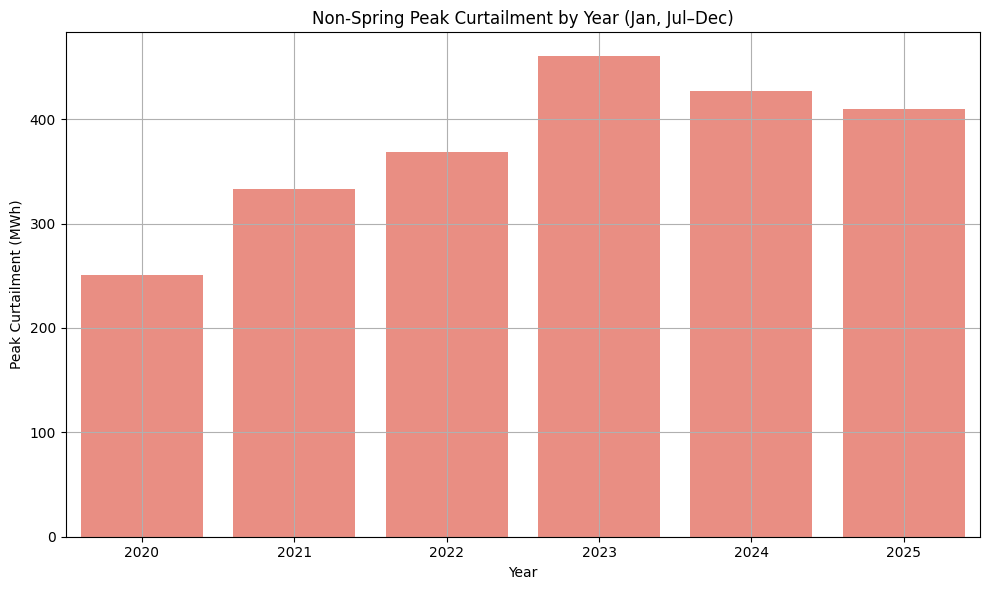

In [40]:
# Group by year and calculate metrics
non_spring_summary = non_peak_df.groupby('Year')['Total Curtailment (MW) (MWh)'].agg(
    NonSpring_Total_Curtailment_MWh='sum',
    NonSpring_Average_Daily_Curtailment_MWh='mean',
    NonSpring_Peak_Curtailment_MWh='max'
).reset_index()

# Plotting peak curtailment during non-spring for each year
plt.figure(figsize=(10, 6))
sns.barplot(data=non_spring_summary, x='Year', y='NonSpring_Peak_Curtailment_MWh', color='salmon')
plt.title("Non-Spring Peak Curtailment by Year (Jan, Jul–Dec)")
plt.ylabel("Peak Curtailment (MWh)")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()

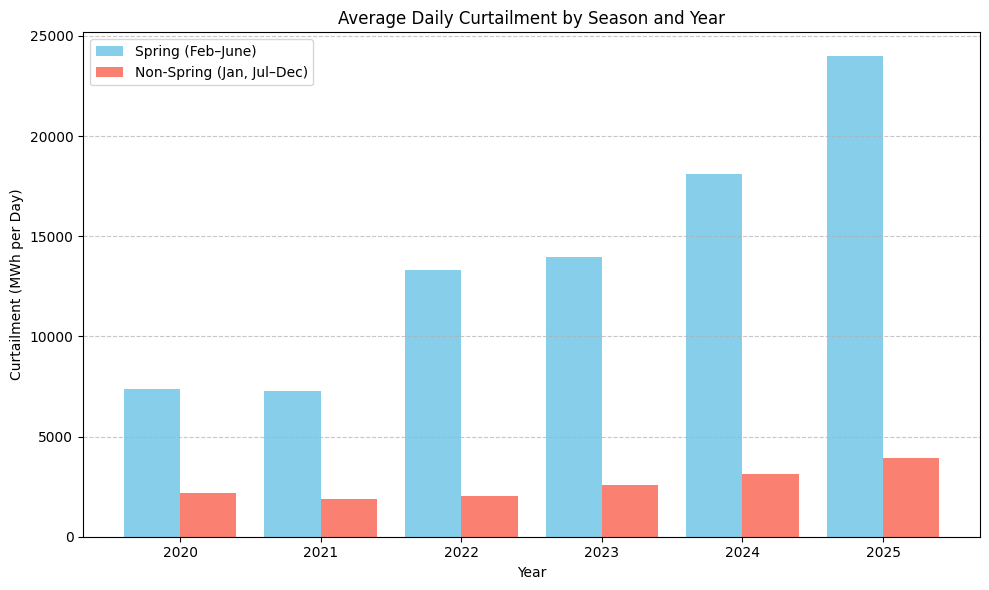

In [41]:
# Step 1: Group by Date to get daily totals
daily_totals = curtailment_df.groupby(['Date']).agg(
    Daily_Curtailment_MWh=('Total Curtailment (MW) (MWh)', 'sum')
).reset_index()

# Extract Year and Month from Date
daily_totals['Year'] = pd.to_datetime(daily_totals['Date']).dt.year
daily_totals['Month_Num'] = pd.to_datetime(daily_totals['Date']).dt.month

# Step 2: Define Spring vs Non-Spring
spring_months = [2, 3, 4, 5, 6]
spring_df = daily_totals[daily_totals['Month_Num'].isin(spring_months)]
non_spring_df = daily_totals[~daily_totals['Month_Num'].isin(spring_months)]

# Step 3: Group and summarize
spring_summary = spring_df.groupby('Year')['Daily_Curtailment_MWh'].mean().reset_index(name='Spring_Daily_Avg_MWh')
non_spring_summary = non_spring_df.groupby('Year')['Daily_Curtailment_MWh'].mean().reset_index(name='NonSpring_Daily_Avg_MWh')

# Step 4: Merge and Plot
season_comparison = pd.merge(spring_summary, non_spring_summary, on='Year')

# Plotting
plt.figure(figsize=(10, 6))
bar_width = 0.4
x = range(len(season_comparison))

plt.bar(x, season_comparison['Spring_Daily_Avg_MWh'], width=bar_width, label='Spring (Feb–June)', color='skyblue')
plt.bar([i + bar_width for i in x], season_comparison['NonSpring_Daily_Avg_MWh'], width=bar_width, label='Non-Spring (Jan, Jul–Dec)', color='salmon')

plt.xticks([i + bar_width / 2 for i in x], season_comparison['Year'].astype(str))
plt.title("Average Daily Curtailment by Season and Year")
plt.ylabel("Curtailment (MWh per Day)")
plt.xlabel("Year")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [42]:
curtailment_df

,Date,Hour,Interval,Wind Curtailment,Solar Curtailment,Year,Reason,Total Curtailment (MW),Datetime,Solar Curtailment (MWh),Wind Curtailment (MWh),Total Curtailment (MW) (MWh),Month_Num
0,2020-01-01 00:00:00,9,5,0.000000,1.960000,2020,NaN,1.960000,2020-01-01 01:20:00,0.163333,0.000000,0.163333,1
1,2020-01-01 00:00:00,9,6,0.000000,10.430918,2020,NaN,10.430918,2020-01-01 01:25:00,0.869243,0.000000,0.869243,1
2,2020-01-01 00:00:00,9,10,0.000000,1.295686,2020,NaN,1.295686,2020-01-01 01:45:00,0.107974,0.000000,0.107974,1
3,2020-01-01 00:00:00,9,11,40.030000,153.010799,2020,NaN,193.040799,2020-01-01 01:50:00,12.750900,3.335833,16.086733,1
4,2020-01-01 00:00:00,9,12,26.946634,161.819285,2020,NaN,188.765920,2020-01-01 01:55:00,13.484940,2.245553,15.730493,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
266404,2025-03-31 07:00:00,18,3,0.000000,8.289998,2025,System,8.289998,2025-03-31 17:10:00,0.690833,0.000000,0.690833,4
266405,2025-03-31 07:00:00,18,4,0.000000,5.191092,2025,System,5.191092,2025-03-31 17:15:00,0.432591,0.000000,0.432591,4
266406,2025-03-31 07:00:00,18,8,0.000000,7.423253,2025,Local,7.423253,2025-03-31 17:35:00,0.618604,0.000000,0.618604,4
266407,2025-03-31 07:00:00,18,9,0.000000,7.619995,2025,Local,7.619995,2025-03-31 17:40:00,0.635000,0.000000,0.635000,4


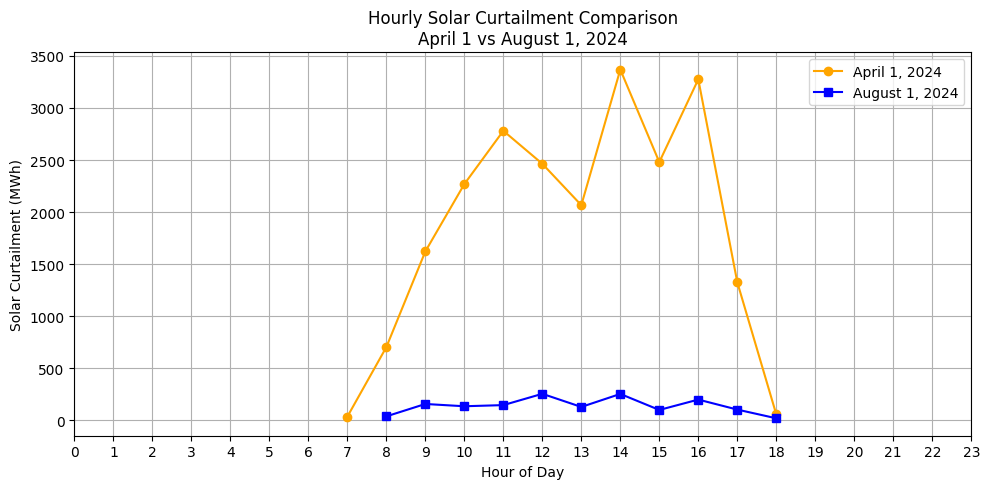

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# If not already in datetime format
curtailment_df['Datetime'] = pd.to_datetime(curtailment_df['Datetime'])

# Extract date and hour for grouping
curtailment_df['Date'] = curtailment_df['Datetime'].dt.date
curtailment_df['Hour'] = curtailment_df['Datetime'].dt.hour

# Fill NaNs in Solar Curtailment column
curtailment_df['Solar Curtailment (MWh)'] = curtailment_df['Solar Curtailment (MWh)'].fillna(0)

# Filter for April 1, 2024
apr1_df = curtailment_df[curtailment_df['Date'] == pd.to_datetime("2024-04-01").date()]
apr1_hourly = apr1_df.groupby('Hour')['Solar Curtailment (MWh)'].sum()

# Filter for August 1, 2024
aug1_df = curtailment_df[curtailment_df['Date'] == pd.to_datetime("2024-08-01").date()]
aug1_hourly = aug1_df.groupby('Hour')['Solar Curtailment (MWh)'].sum()

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(apr1_hourly.index, apr1_hourly.values, marker='o', label='April 1, 2024', color='orange')
plt.plot(aug1_hourly.index, aug1_hourly.values, marker='s', label='August 1, 2024', color='blue')
plt.title("Hourly Solar Curtailment Comparison\nApril 1 vs August 1, 2024")
plt.xlabel("Hour of Day")
plt.ylabel("Solar Curtailment (MWh)")
plt.grid(True)
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()